In [1]:
1

1

In [2]:
# CAMB v2 LateDE

import numpy as np
import matplotlib.pyplot as plt
import camb
import os

# Check which CAMB is installed
print(
    "Using CAMB %s installed at %s"
    % (camb.__version__, os.path.dirname(camb.__file__))
)

Using CAMB 2.0.2 installed at /gpfs/scratch/pit-roman-hlis/Diogo/CAMBv2LateDE/camb


# All parameterizations

In [3]:
# Common cosmological parameters
base_params = dict(
    H0=70,ombh2=0.02238280,omch2=0.1201075,TCMB=2.7255,dark_energy_model="ppf",
    # Neutrinos
    omnuh2=0,num_nu_massless=3.044,num_nu_massive=0,nu_mass_degeneracies=[0],nu_mass_numbers=[0],
    # Initial power spectrum
    As=2.100549e-9,ns=0.9660499,YHe=0.246,WantTransfer=True
    )

# ------------------------------------------------------------
# DEmodel = 1: constant w
# ------------------------------------------------------------
cosmology_w = camb.set_params(**base_params,DEmodel=1,w0=-0.8)

# ------------------------------------------------------------
# DEmodel = 2: CPL
# w(a) = w0 + (1-a) w1
# ------------------------------------------------------------
cosmology_cpl = camb.set_params(**base_params,DEmodel=2,w0=-0.8,w1=-0.3)

# ------------------------------------------------------------
# DEmodel = 3: piecewise-constant binned w(z)
# ------------------------------------------------------------
z_knot = [0.5 * (i + 1) for i in range(20)]
w_knot = [-1 + 0.3 * np.sin(i) for i in range(20)]

cosmology_bins = camb.set_params(**base_params,DEmodel=3,z_knot=z_knot,w_knot=w_knot)

# ------------------------------------------------------------
# DEmodel = 4: Flexknots
# ------------------------------------------------------------
a_flexknot=[0.0,0.35,0.60,0.80,1.0]
w_flexknot=[-1.0,-0.7,-1.4,-0.8,-1.1]
cosmology_flexknot = camb.set_params(**base_params,DEmodel=4,a_flexknot=a_flexknot,w_flexknot=w_flexknot)

# Background sampling
scale_factor = np.logspace(-2, 0, 2000)
redshift = 1 / scale_factor - 1

# ------------------------------------------------------------
# Compute dark-energy background evolution
# ------------------------------------------------------------
results_w = camb.get_results(cosmology_w)
rho_w, wde_w = results_w.get_dark_energy_rho_w(scale_factor)

results_cpl = camb.get_results(cosmology_cpl)
rho_cpl, wde_cpl = results_cpl.get_dark_energy_rho_w(scale_factor)

results_bins = camb.get_results(cosmology_bins)
rho_bins, wde_bins = results_bins.get_dark_energy_rho_w(scale_factor)

results_flexknot = camb.get_results(cosmology_flexknot)
rho_flexnot, wde_flexknot = results_flexknot.get_dark_energy_rho_w(scale_factor)

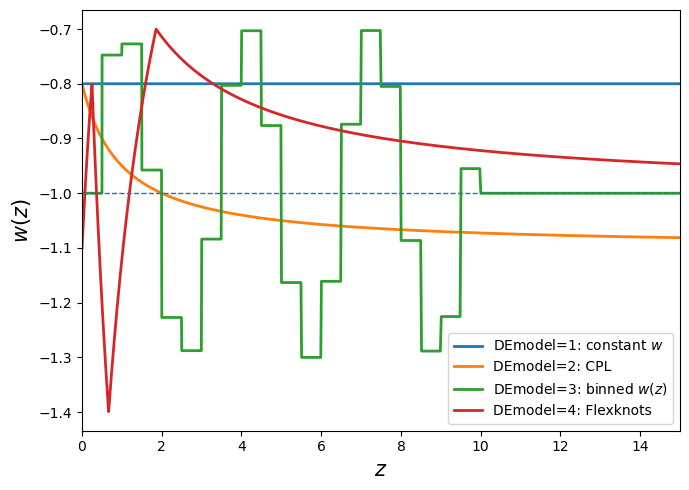

In [4]:
# ------------------------------------------------------------
# Plot w(z)
# ------------------------------------------------------------
plt.figure(figsize=(7, 5))

plt.plot(redshift,wde_w,lw=2,label=r"DEmodel=1: constant $w$")
plt.plot(redshift,wde_cpl,lw=2,label=r"DEmodel=2: CPL")
plt.plot(redshift,wde_bins,lw=2,label=r"DEmodel=3: binned $w(z)$")
plt.plot(redshift,wde_flexknot,lw=2,label=r"DEmodel=4: Flexknots")

plt.axhline(-1, lw=1, ls="--")

plt.xlim(0, 15)
plt.ylabel(r"$w(z)$", fontsize=15)
plt.xlabel(r"$z$", fontsize=15)
plt.legend(loc="best")
plt.tight_layout()

# plt.savefig("latede_models_w.pdf")
plt.show()

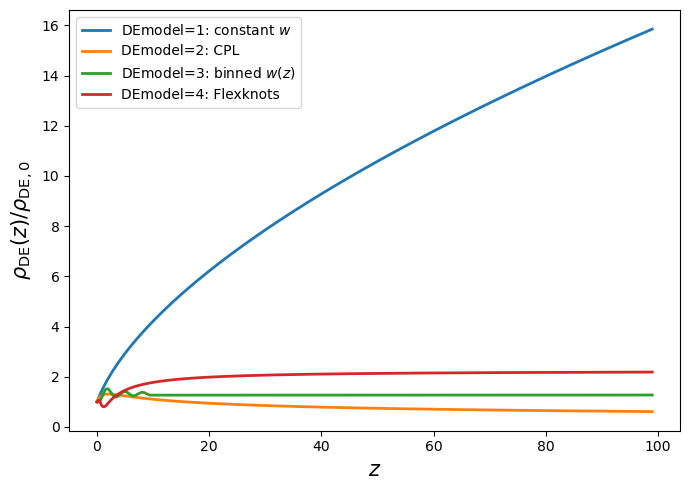

In [5]:
# ------------------------------------------------------------
# Plot rho_DE(a) / rho_DE(a=1)
# ------------------------------------------------------------
plt.figure(figsize=(7, 5))

plt.plot(redshift,rho_w / rho_w[-1],lw=2,label=r"DEmodel=1: constant $w$")
plt.plot(redshift,rho_cpl / rho_cpl[-1],lw=2,label=r"DEmodel=2: CPL")
plt.plot(redshift,rho_bins / rho_bins[-1],lw=2,label=r"DEmodel=3: binned $w(z)$")
plt.plot(redshift,rho_flexnot / rho_flexnot[-1],lw=2,label=r"DEmodel=4: Flexknots")

# plt.xlim(0, 1)
plt.ylabel(r"$\rho_{\rm DE}(z)/\rho_{\rm DE,0}$", fontsize=15)
plt.xlabel(r"$z$", fontsize=15)
plt.legend(loc="best")
plt.tight_layout()
# plt.savefig("latede_models_rho.pdf")
plt.show()

# Flexknots

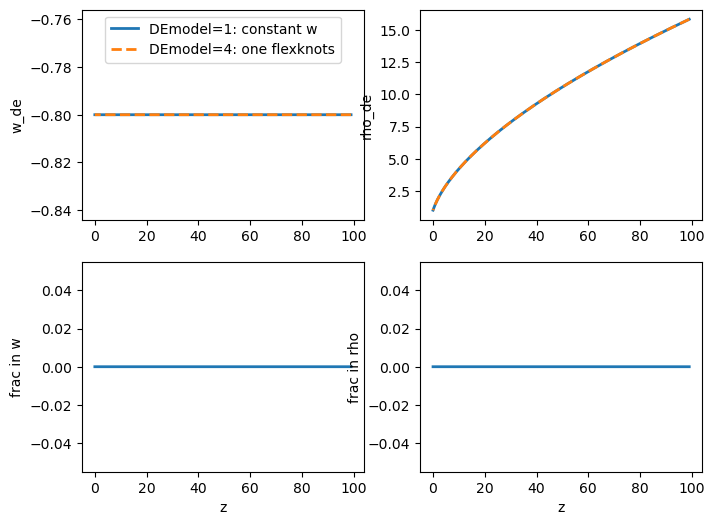

In [6]:
# One knot vs constant w
cosmology_1flexknot = camb.set_params(**base_params,DEmodel=4,a_flexknot=[1.],w_flexknot=[-.8])

# Compute
results_1flexknot = camb.get_results(cosmology_1flexknot)
rho_1flexnot, wde_1flexknot = results_1flexknot.get_dark_energy_rho_w(scale_factor)

fig,ax = plt.subplots(2,2,figsize=(8,6))
ax[0,0].plot(redshift,wde_w,lw=2,label=r"DEmodel=1: constant w")
ax[0,0].plot(redshift,wde_1flexknot,lw=2,ls='--',label=r"DEmodel=4: one flexknots")
ax[0,1].plot(redshift,rho_w / rho_1flexnot[-1],lw=2)
ax[0,1].plot(redshift,rho_w / rho_1flexnot[-1],lw=2,ls='--')
ax[1,0].plot(redshift,wde_w/wde_1flexknot-1,lw=2)
ax[1,1].plot(redshift,rho_w/rho_1flexnot-1,lw=2)
[ax[1,i].set_xlabel("z") for i in [0,1]]
ax[0,0].set_ylabel("w_de")
ax[0,1].set_ylabel("rho_de")
ax[1,0].set_ylabel("frac in w")
ax[1,1].set_ylabel("frac in rho")
ax[0,0].legend(loc='upper center')

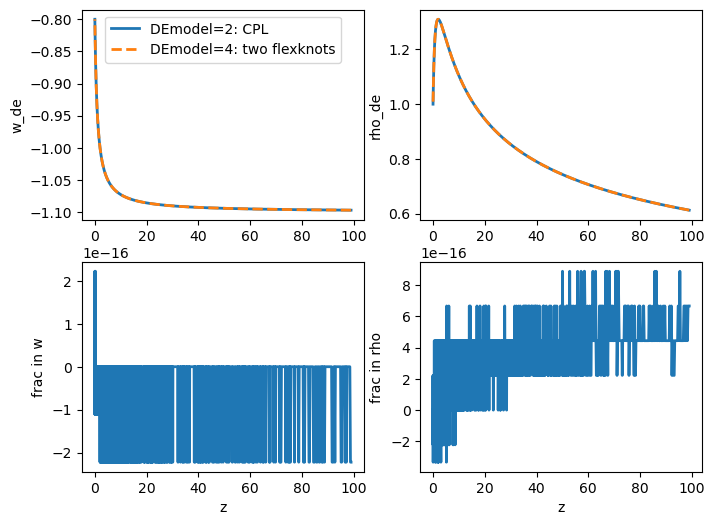

In [7]:
# Two knots vs CPL
w0=-0.8
wa=-0.3

a_flexknot=[0., 1.]
w_flexknot=[w0+wa, w0]

cosmology_2flexknot = camb.set_params(**base_params,DEmodel=4,a_flexknot=a_flexknot,w_flexknot=w_flexknot)

# Compute
results_2flexknot = camb.get_results(cosmology_2flexknot)
rho_2flexnot, wde_2flexknot = results_2flexknot.get_dark_energy_rho_w(scale_factor)

fig,ax = plt.subplots(2,2,figsize=(8,6))
ax[0,0].plot(redshift,wde_cpl,lw=2,label=r"DEmodel=2: CPL")
ax[0,0].plot(redshift,wde_2flexknot,lw=2,ls='--',label=r"DEmodel=4: two flexknots")
ax[0,1].plot(redshift,rho_cpl / rho_cpl[-1],lw=2)
ax[0,1].plot(redshift,rho_2flexnot / rho_2flexnot[-1],lw=2,ls='--')
ax[1,0].plot(redshift,wde_cpl/wde_2flexknot-1,lw=2)
ax[1,1].plot(redshift,rho_cpl/rho_2flexnot-1,lw=2)
[ax[1,i].set_xlabel("z") for i in [0,1]]
ax[0,0].set_ylabel("w_de")
ax[0,1].set_ylabel("rho_de")
ax[1,0].set_ylabel("frac in w")
ax[1,1].set_ylabel("frac in rho")
ax[0,0].legend(loc='upper center')

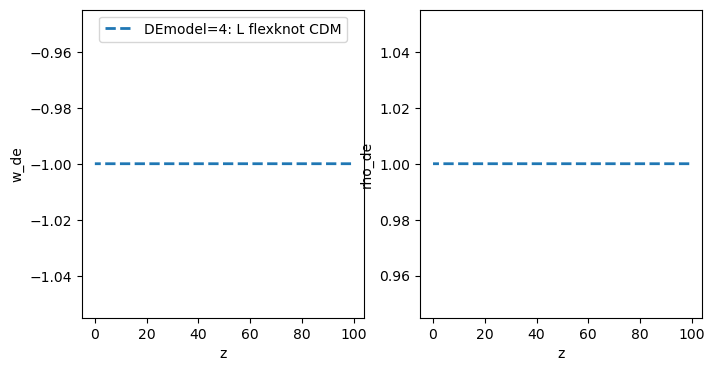

In [8]:
# Pure ΛCDM flexknot
a_flexknot=[0., 0.2, 0.6, 0.9, 1.]
w_flexknot=[-1., -1., -1., -1., -1.]

cosmology_lflexknotcdm = camb.set_params(**base_params,DEmodel=4,a_flexknot=a_flexknot,w_flexknot=w_flexknot)

# Compute
results_lflexknotcdm = camb.get_results(cosmology_lflexknotcdm)
rho_lflexknotcdm, wde_lflexknotcdm = results_lflexknotcdm.get_dark_energy_rho_w(scale_factor)

fig,ax = plt.subplots(1,2,figsize=(8,4))
ax[0].plot(redshift,wde_lflexknotcdm,lw=2,ls='--',label=r"DEmodel=4: L flexknot CDM")
ax[1].plot(redshift,rho_lflexknotcdm / rho_lflexknotcdm[-1],lw=2,ls='--')
[ax[i].set_xlabel("z") for i in [0,1]]
ax[0].set_ylabel("w_de")
ax[1].set_ylabel("rho_de")
ax[0].legend(loc='upper center')

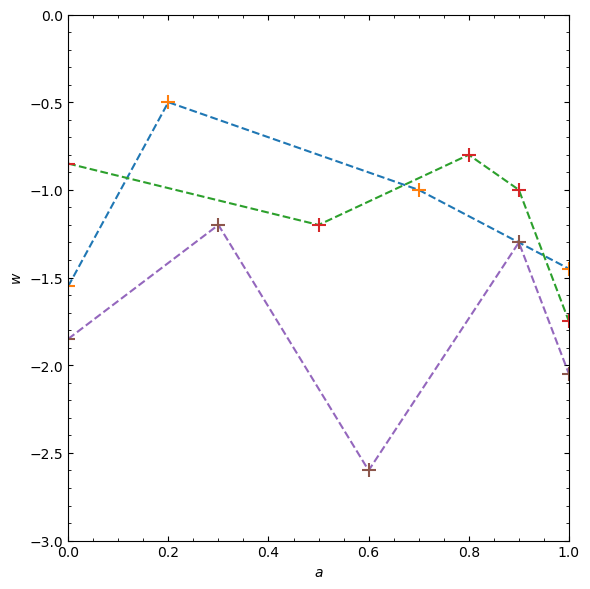

In [ ]:
# ------------------------------------------------------------
# Approximate knot coordinates read from Fig. 1 of
# Ormondroyd et al. 2025, arXiv:2503.08658
# ------------------------------------------------------------

examples = [
    (
        [0.0, 0.20, 0.70, 1.0],
        [-1.55, -0.50, -1.00, -1.45],
    ),
    (
        [0.0, 0.50, 0.80, 0.90, 1.0],
        [-0.85, -1.20, -0.80, -1.00, -1.75],
    ),
    (
        [0.0, 0.30, 0.60, 0.90, 1.0],
        [-1.85, -1.20, -2.60, -1.30, -2.05],
    ),
]

agrid = np.linspace(1e-4, 1.0, 1000)
fig, ax = plt.subplots(figsize=(6, 6))

for a_knot, w_knot in examples:
    pars = camb.set_params(**base_params,DEmodel=4,a_flexknot=a_knot,w_flexknot=w_knot)
    results = camb.get_results(pars)
    rho, wde = results.get_dark_energy_rho_w(agrid)
    ax.plot(agrid,wde,'--',lw=1.5)
    ax.plot(a_knot,w_knot,'+',ms=10,mew=1.5)

ax.set_xlim(0, 1)
ax.set_ylim(-3, 0)

ax.set_xlabel(r'$a$')
ax.set_ylabel(r'$w$')

ax.minorticks_on()
ax.tick_params(which='both',direction='in',top=True,right=True)

plt.tight_layout()
plt.show()